In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import black_litterman
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, EfficientFrontier, expected_returns
import pandas as pd
import joblib  # For saving and loading scalers
import matplotlib.pyplot as plt  # For plotting
from tensorflow.keras.models import Sequential, load_model
import warnings
warnings.filterwarnings("ignore")

In [37]:
risk_free_rate = 0.06  # Risk free rate

In [67]:
# data = pd.read_csv("Top_4_stocks.csv")
# data["Date"] = pd.to_datetime(data['Date'])
# data.set_index("Date", inplace=True)
# data.head(10)


mcap = pd.read_csv("mcap.csv", index_col=0)
mcap.index = pd.to_datetime(mcap.index)

data = pd.read_csv('prices.csv', index_col=0)
data.index = pd.to_datetime(data.index)

data.head()

,NTPC,PWGR,TCS,WPRO,DLFU,GCPL,LT,SIEM,SUNP,CIPLA,HDFCB,ICICIBC,RELIANCE,ONGC,HUVR,ITC,BHARTI,IDEA,SAIL,HNDL
Date,,,,,,,,,,,,,,,,,,,,
2015-01-01,118.71,77.12,1272.78,103.58,137.40,321.97,1001.97,906.70,822.20,628.40,476.03,320.27,200.33,229.37,758.45,231.55,327.07,96.25,82.75,158.45
2015-01-02,120.33,78.05,1289.72,104.49,139.20,323.37,1023.10,914.35,826.25,630.15,482.65,329.36,199.80,232.80,755.95,232.28,329.00,96.58,82.85,160.10
2015-01-05,120.00,78.13,1270.13,104.68,135.80,323.48,1037.33,918.65,826.75,633.00,478.58,330.05,197.61,235.43,760.30,233.19,321.70,92.74,82.70,156.85
2015-01-06,116.00,76.39,1223.30,102.23,133.65,317.33,1002.73,895.70,808.55,614.35,471.13,316.05,188.64,222.10,774.70,227.20,319.18,90.90,78.65,153.40
2015-01-07,118.79,77.48,1208.85,101.46,134.60,320.05,1000.33,899.20,809.80,611.95,472.50,307.50,192.75,225.37,801.90,222.98,319.95,90.45,77.80,148.90


In [68]:
cols = data.columns.tolist()[:13]
data = data[cols]
mcap = mcap[cols]

In [69]:
mcap.loc[pd.to_datetime("2018-01-08")].to_dict()

{'NTPC': 1464806.6906,
 'PWGR': 1049195.2648,
 'TCS': 5196141.99,
 'WPRO': 1407520.7779,
 'DLFU': 464300.7916,
 'GCPL': 677718.4944,
 'LT': 1874930.5936,
 'SIEM': 460623.7438,
 'SUNP': 1419396.0687,
 'CIPLA': 495081.2242,
 'HDFCB': 4819184.0316,
 'ICICIBC': 2017569.2265,
 'RELIANCE': 5880974.6926}

In [70]:
assets = data.columns
assets

Index(['NTPC', 'PWGR', 'TCS', 'WPRO', 'DLFU', 'GCPL', 'LT', 'SIEM', 'SUNP',
       'CIPLA', 'HDFCB', 'ICICIBC', 'RELIANCE'],
      dtype='object')

In [71]:
def annualize_returns(returns, horizon=3):
    trading_days_per_year = 252
    annualized_returns = (1 + returns) ** (trading_days_per_year / horizon) - 1
    return annualized_returns

In [72]:
training_dates = []
testing_dates = []

start_date = data.index[0 + 3]
end_date = data.index[-1]

# Generate training and testing date ranges
while start_date + pd.DateOffset(years=4) <= end_date:
    training_dates.append((start_date, start_date + pd.DateOffset(years=3)))
    testing_dates.append((start_date + pd.DateOffset(years=3), start_date + pd.DateOffset(years=4)))
    start_date += pd.DateOffset(years=1)

In [73]:
training_dates, testing_dates

([(Timestamp('2015-01-06 00:00:00'), Timestamp('2018-01-06 00:00:00')),
  (Timestamp('2016-01-06 00:00:00'), Timestamp('2019-01-06 00:00:00')),
  (Timestamp('2017-01-06 00:00:00'), Timestamp('2020-01-06 00:00:00')),
  (Timestamp('2018-01-06 00:00:00'), Timestamp('2021-01-06 00:00:00')),
  (Timestamp('2019-01-06 00:00:00'), Timestamp('2022-01-06 00:00:00')),
  (Timestamp('2020-01-06 00:00:00'), Timestamp('2023-01-06 00:00:00')),
  (Timestamp('2021-01-06 00:00:00'), Timestamp('2024-01-06 00:00:00'))],
 [(Timestamp('2018-01-06 00:00:00'), Timestamp('2019-01-06 00:00:00')),
  (Timestamp('2019-01-06 00:00:00'), Timestamp('2020-01-06 00:00:00')),
  (Timestamp('2020-01-06 00:00:00'), Timestamp('2021-01-06 00:00:00')),
  (Timestamp('2021-01-06 00:00:00'), Timestamp('2022-01-06 00:00:00')),
  (Timestamp('2022-01-06 00:00:00'), Timestamp('2023-01-06 00:00:00')),
  (Timestamp('2023-01-06 00:00:00'), Timestamp('2024-01-06 00:00:00')),
  (Timestamp('2024-01-06 00:00:00'), Timestamp('2025-01-06 00:0

In [74]:
t1 = pd.Timestamp("2024-03-11 10:30:00")
t2 = pd.Timestamp("2025-03-18 15:45:00")

def get_model_name(stock_name, idx):
    model_name = f"{stock_name}_{training_dates[idx][0].strftime('%Y%m%d')}_{training_dates[idx][1].strftime('%Y%m%d')}"
    print(model_name)
    return model_name

get_model_name(assets[1],0)

PWGR_20150106_20180106


'PWGR_20150106_20180106'

In [75]:
[d[1] for d in testing_dates]

[Timestamp('2019-01-06 00:00:00'),
 Timestamp('2020-01-06 00:00:00'),
 Timestamp('2021-01-06 00:00:00'),
 Timestamp('2022-01-06 00:00:00'),
 Timestamp('2023-01-06 00:00:00'),
 Timestamp('2024-01-06 00:00:00'),
 Timestamp('2025-01-06 00:00:00')]

In [83]:
import scipy.optimize as sco  # Import scipy.optimize as sco

def min_volatility_weights(mu, S):
    ef = EfficientFrontier(mu, S, weight_bounds=(0, 0.5))
    ef.min_volatility()
    cleaned_weights = ef.clean_weights()
    return cleaned_weights


def max_sharpe_ratio(mu, S):
    
    num_assets = len(mu)
    
    def sharpe_ratio(weights):
        weights = np.array(weights)
        port_return = np.dot(weights, mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(S, weights)))
        return -(port_return - risk_free_rate) / port_volatility  # Negative for minimization
    
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Sum of weights must be 1
    bounds = tuple((0.0,0.50) for _ in range(num_assets))  # No short selling
    initial_weights = np.ones(num_assets) / num_assets  # Equal allocation start
    
    result = sco.minimize(sharpe_ratio, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints, options={'disp': False, 'maxiter': 1000})
    
    optimal_weights = result.x
    cleaned_weights = {asset: weight for asset, weight in zip(data.columns, optimal_weights)}
    return cleaned_weights    

    


In [84]:
def backtest(strategy):

    start_date = pd.to_datetime("2018-01-08")
    end_date = pd.to_datetime("2025-01-08")

    # initial_weights = mcaps / mcaps.sum()  # Market-cap weights (Needs to be adjusted based on data)
    # initial_weights = {ticker: 1/len(assets) for ticker in assets}  # Equal weights

    # mcaps_dict = mcap.loc[start_date].to_dict()

    initial_investment = 100  # Initial portfolio value
    portfolio_value = [initial_investment]
    dates = [start_date]

    model_change_dates = [d[1] for d in testing_dates]  # All the dates when the model changes
    model_number = 0

    # Rebalancing frequency (e.g., every 5 days)
    rebalance_frequency = 3

    # Initial model for each asset
    model_dict = {}
    for asset in assets:
        model_name = get_model_name(asset, model_number)
        model = load_model(f"models/{model_name}.h5")
        scaler = joblib.load(f"models/{model_name}_scaler.pkl")
        model_dict[asset] = [model, scaler]

    # List to store weights
    W = []

    # Backtest loop
    current_date = start_date
    last_rebalance_date = start_date
    previous_weights = None

    while current_date < end_date:
        # Prepare input data for LSTM predictions
        Q = {}
        for stock_name, (model, scaler) in model_dict.items():
            input_data = data.loc[:current_date, stock_name].tail(30).values.reshape(-1, 1)
            scaled_input_data = scaler.transform(input_data)
            # print(stock_name)
            # Predict 5-day returns using the LSTM model
            scaled_predicted_returns = model.predict(scaled_input_data.reshape(1, 30, 1), verbose=0)
            predicted_returns = scaler.inverse_transform(scaled_predicted_returns)[0]
            # print(predicted_returns)
            # Annualize the predicted returns
            # predicted_returns = annualize_returns(predicted_returns[0], horizon=3)
            predicted_returns = predicted_returns[0] * (252/3) * (1/15)
            # print(predicted_returns)

            # if predicted_returns > 100:
            #     predicted_returns = 0.20
            # elif predicted_returns > 50:
            #     predicted_returns = 0.10
            # elif predicted_returns > 0:
            #     predicted_returns = 0.05
            # elif predicted_returns > -50:
            #     predicted_returns = -0.05
            # elif predicted_returns > -100:
            #     predicted_returns = -0.10
           
            
            Q[stock_name] = predicted_returns

        # View dictionary for Black-Litterman
        viewdict = Q
        
        # Covariance matrix (S)
        S = risk_models.sample_cov(data.loc[:current_date])

        # Risk aversion parameter
        # delta = 2.5  
        delta = black_litterman.market_implied_risk_aversion(data.loc[:current_date])

    
        # Market-implied prior returns
        prior = black_litterman.market_implied_prior_returns(mcap.loc[start_date].to_dict(), delta, S)
        # prior = black_litterman.market_implied_prior_returns(initial_weights, delta, S)
        # print(f"Prior returns: {prior}")

        # Black-Litterman model
        bl = BlackLittermanModel(S, pi=prior, absolute_views=viewdict)
        bl_returns = bl.bl_returns()
        bl_cov = bl.bl_cov()
        # print(f"BL returns: {bl_returns}")

        # Efficient Frontier optimization
        # ef = EfficientFrontier(bl_returns, S)
        # ef.min_volatility()
        # cleaned_weights = ef.clean_weights()

        # cleaned_weights = min_volatility_weights(bl_returns, S)  # Use min_volatility_weights function
        cleaned_weights = strategy(bl_returns, bl_cov)  # Use max_sharpe_ratio function
        
        # print(f"Cleaned Weights on {current_date}: {cleaned_weights}")
        # Check rebalancing conditions
        should_rebalance = False
        days_since_rebalance = (current_date - last_rebalance_date).days
        # print("-" * 20)
        # Condition 1: Every 5 days
        if days_since_rebalance >= rebalance_frequency:
            should_rebalance = True
        
        # Condition 2: Weights change by 60% or more
        if previous_weights is not None:
            weight_diff = sum(abs(cleaned_weights.get(stock, 0) - previous_weights.get(stock, 0)) 
                            for stock in set(cleaned_weights.keys()) | set(previous_weights.keys()))
            if weight_diff >= 0.6:  # 60% threshold
                should_rebalance = True

        if should_rebalance:
            W.append(cleaned_weights)
            previous_weights = cleaned_weights.copy()
            last_rebalance_date = current_date
            
            # Compute portfolio returns for the next rebalance period
            curr_date_index = data.index.get_loc(current_date)
            next_index = min(curr_date_index + rebalance_frequency, len(data) - 1)
            next_date = data.index[next_index]

            # Get actual returns for the rebalance period
            actual_returns = data.loc[current_date:next_date].pct_change().dropna()

            # Ensure cleaned_weights is aligned correctly
            cleaned_weights_series = pd.Series(cleaned_weights)
            
            # Compute portfolio return
            portfolio_returns = (actual_returns @ cleaned_weights_series).values

            # Ensure equal length between portfolio_value and dates
            for j in range(len(portfolio_returns)):
                new_value = portfolio_value[-1] * (1 + portfolio_returns[j])
                portfolio_value.append(new_value)
                dates.append(actual_returns.index[j])  # Append correct date

            # print(f"Portfolio value at {next_date}: {portfolio_value[-1]}")
            
            # Move to the next rebalance date
            current_date = next_date
        else:
            # Move forward one day if no rebalancing
            curr_date_index = data.index.get_loc(current_date)
            current_date = data.index[min(curr_date_index + 1, len(data) - 1)]

        # Model change logic
        if model_number < len(model_change_dates) and current_date >= model_change_dates[model_number]:
            model_number += 1
            try:
                for asset in assets:
                    model_name = get_model_name(asset, model_number)
                    model = load_model(f"models/{model_name}.h5")
                    scaler = joblib.load(f"models/{model_name}_scaler.pkl")
                    model_dict[asset] = [model, scaler]
            except Exception as e:
                print(f"Error loading new model: {e}")
                break

    # Final portfolio value
    print(f"Final portfolio value: {portfolio_value[-1]}")
    return portfolio_value, dates, W



In [85]:
portfolio_value_BL_MS, dates_BL_MS, W_BL_MS = backtest(max_sharpe_ratio)

NTPC_20150106_20180106
PWGR_20150106_20180106
TCS_20150106_20180106
WPRO_20150106_20180106
DLFU_20150106_20180106
GCPL_20150106_20180106
LT_20150106_20180106
SIEM_20150106_20180106
SUNP_20150106_20180106
CIPLA_20150106_20180106
HDFCB_20150106_20180106
ICICIBC_20150106_20180106
RELIANCE_20150106_20180106
NTPC_20160106_20190106
PWGR_20160106_20190106
TCS_20160106_20190106
WPRO_20160106_20190106
DLFU_20160106_20190106
GCPL_20160106_20190106
LT_20160106_20190106
SIEM_20160106_20190106
SUNP_20160106_20190106
CIPLA_20160106_20190106
HDFCB_20160106_20190106
ICICIBC_20160106_20190106
RELIANCE_20160106_20190106
NTPC_20170106_20200106
PWGR_20170106_20200106
TCS_20170106_20200106
WPRO_20170106_20200106
DLFU_20170106_20200106
GCPL_20170106_20200106
LT_20170106_20200106
SIEM_20170106_20200106
SUNP_20170106_20200106
CIPLA_20170106_20200106
HDFCB_20170106_20200106
ICICIBC_20170106_20200106
RELIANCE_20170106_20200106
NTPC_20180106_20210106
PWGR_20180106_20210106
TCS_20180106_20210106
WPRO_20180106_202

In [86]:
portfolio_value_BL_MV, dates_BL_MV, W_BL_MV = backtest(min_volatility_weights)

NTPC_20150106_20180106
PWGR_20150106_20180106
TCS_20150106_20180106
WPRO_20150106_20180106
DLFU_20150106_20180106
GCPL_20150106_20180106
LT_20150106_20180106
SIEM_20150106_20180106
SUNP_20150106_20180106
CIPLA_20150106_20180106
HDFCB_20150106_20180106
ICICIBC_20150106_20180106
RELIANCE_20150106_20180106
NTPC_20160106_20190106
PWGR_20160106_20190106
TCS_20160106_20190106
WPRO_20160106_20190106
DLFU_20160106_20190106
GCPL_20160106_20190106
LT_20160106_20190106
SIEM_20160106_20190106
SUNP_20160106_20190106
CIPLA_20160106_20190106
HDFCB_20160106_20190106
ICICIBC_20160106_20190106
RELIANCE_20160106_20190106
NTPC_20170106_20200106
PWGR_20170106_20200106
TCS_20170106_20200106
WPRO_20170106_20200106
DLFU_20170106_20200106
GCPL_20170106_20200106
LT_20170106_20200106
SIEM_20170106_20200106
SUNP_20170106_20200106
CIPLA_20170106_20200106
HDFCB_20170106_20200106
ICICIBC_20170106_20200106
RELIANCE_20170106_20200106
NTPC_20180106_20210106
PWGR_20180106_20210106
TCS_20180106_20210106
WPRO_20180106_202

In [87]:
def backtest_normal(strategy):
    start_date = pd.to_datetime("2018-01-08")
    end_date = pd.to_datetime("2025-01-08")

    # initial_weights = mcaps / mcaps.sum()  # Market-cap weights (Needs to be adjusted based on data)
    initial_investment = 100  # Initial portfolio value
    portfolio_value = [initial_investment]
    dates = [start_date]

    rebalance_frequency = 3

    W = []                     

    # Backtest loop
    current_date = start_date
    last_rebalance_date = start_date
    previous_weights = None

    # Number of assets (to compute equal weights)
    n_assets = len(assets)
    equal_weight = 1.0 / n_assets  # Equal weight for each asset

    while current_date < end_date:
        # Assign equal weights to all assets
        if strategy == "ew":
            cleaned_weights = {stock: equal_weight for stock in assets}
        
        if strategy == "ms":
            S = risk_models.sample_cov(data.loc[:current_date])
            mu = expected_returns.mean_historical_return(data.loc[:current_date])
            cleaned_weights = max_sharpe_ratio(mu, S)
        
        if strategy == "mv":
            S = risk_models.sample_cov(data.loc[:current_date])
            mu = expected_returns.mean_historical_return(data.loc[:current_date])
            cleaned_weights = min_volatility_weights(mu, S)
            

        # Check rebalancing conditions
        should_rebalance = False
        days_since_rebalance = (current_date - last_rebalance_date).days
        
        # Condition 1: Every 5 days
        if days_since_rebalance >= 3:
            should_rebalance = True
        
        # Condition 2: Weights change by 60% or more
        if previous_weights is not None:
            weight_diff = sum(abs(cleaned_weights.get(stock, 0) - previous_weights.get(stock, 0)) 
                             for stock in set(cleaned_weights.keys()) | set(previous_weights.keys()))
            if weight_diff >= 0.6:  # 60% threshold
                should_rebalance = True

        if should_rebalance:
            W.append(cleaned_weights)
            previous_weights = cleaned_weights.copy()
            last_rebalance_date = current_date
            
            # Compute portfolio returns for the next rebalance period
            curr_date_index = data.index.get_loc(current_date)
            next_index = min(curr_date_index + rebalance_frequency, len(data) - 1)
            next_date = data.index[next_index]

            # Get actual returns for the rebalance period
            actual_returns = data.loc[current_date:next_date].pct_change().dropna()

            # Ensure cleaned_weights is aligned correctly
            cleaned_weights_series = pd.Series(cleaned_weights)
            
            # Compute portfolio return
            portfolio_returns = (actual_returns @ cleaned_weights_series).values

            # Ensure equal length between portfolio_value and dates
            for j in range(len(portfolio_returns)):
                new_value = portfolio_value[-1] * (1 + portfolio_returns[j])
                portfolio_value.append(new_value)
                dates.append(actual_returns.index[j])  # Append correct date

            # print(f"Portfolio value at {next_date}: {portfolio_value[-1]}")
            
            # Move to the next rebalance date
            current_date = next_date
        else:
            # Move forward one day if no rebalancing
            curr_date_index = data.index.get_loc(current_date)
            current_date = data.index[min(curr_date_index + 1, len(data) - 1)]

    # Final portfolio value
    print(f"Final portfolio value: {portfolio_value[-1]}")
    
    return portfolio_value, dates, W


In [88]:
portfolio_value_normal_ew, dates_normal_ew, W_normal_ew = backtest_normal("ew")
portfolio_value_normal_ms, dates_normal_ms, W_normal_ms = backtest_normal("ms")
portfolio_value_normal_mv, dates_normal_mv, W_normal_mv = backtest_normal("mv")

Final portfolio value: 333.75337151695607
Final portfolio value: 211.448408807034
Final portfolio value: 293.13757809073405


In [89]:
def get_annualized_returns(portfolio_value):
    return (portfolio_value[-1] / portfolio_value[0]) ** (252 / len(portfolio_value)) - 1

def get_sharpe_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    annualized_volatility = portfolio_value.pct_change().std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / annualized_volatility

def get_sortino_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    downside_volatility = portfolio_value.pct_change()[portfolio_value.pct_change() < 0].std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / downside_volatility

def get_max_drawdown(portfolio_value):
    drawdown =  []
    peak = portfolio_value[0]

    for i in range(len(portfolio_value)):
        if portfolio_value[i] >= peak:
            peak = portfolio_value[i]
            drawdown.append(0)
        else:
            drawdown.append((portfolio_value[i] - peak) / peak)
    
    return drawdown

def get_volatility(portfolio_value):
    return portfolio_value.pct_change().std() * np.sqrt(252)

def calculate_yearly_metrics(portfolio_values, dates):
    # Convert to DataFrame with dates as index
    df = pd.DataFrame({
        'portfolio_value': portfolio_values,
        'date': pd.to_datetime(dates)
    }).set_index('date')
    
    # Group by year
    yearly_groups = df.groupby(df.index.year)
    
    results = []
    
    for year, group in yearly_groups:
        if len(group) < 5:  # Skip partial years with insufficient data
            continue
            
        annual_return = get_annualized_returns(group['portfolio_value'])
        sharpe = get_sharpe_ratio(group['portfolio_value'])
        sortino = get_sortino_ratio(group['portfolio_value'])
        max_drawdown = min(get_max_drawdown(group['portfolio_value'])) * 100  # as percentage
        volatility = get_volatility(group['portfolio_value'])
        
        results.append({
            'Year': year,
            'Annual Return (%)': annual_return * 100,
            'Sharpe Ratio': sharpe,
            'Sortino Ratio': sortino,
            'Max Drawdown (%)': max_drawdown,
            'Volatility (%)': volatility * 100
        })
    
    return pd.DataFrame(results).set_index('Year')


In [90]:
import pandas as pd

# Read and prepare data
nifty50 = pd.read_csv("NIFTY_50_Index.csv")
nifty50["Date"] = pd.to_datetime(nifty50["Date"])
nifty50.set_index("Date", inplace=True)

# Filter date range first
nifty50 = nifty50.loc["2018-01-08":"2025-01-08"]
nifty50_dates = nifty50["2018-01-08":"2025-01-08"].index

# Calculate returns on specific column
nifty50_returns = nifty50['^NSEI'].pct_change().dropna()

# Initialize portfolio
nifty50_portfolio = [100]

# Calculate portfolio value
for i in range(len(nifty50_returns)):
    nifty50_portfolio.append(nifty50_portfolio[-1] * (1 + nifty50_returns.iloc[i]))


In [91]:
len(nifty50_portfolio), len(nifty50_dates)

(1725, 1725)

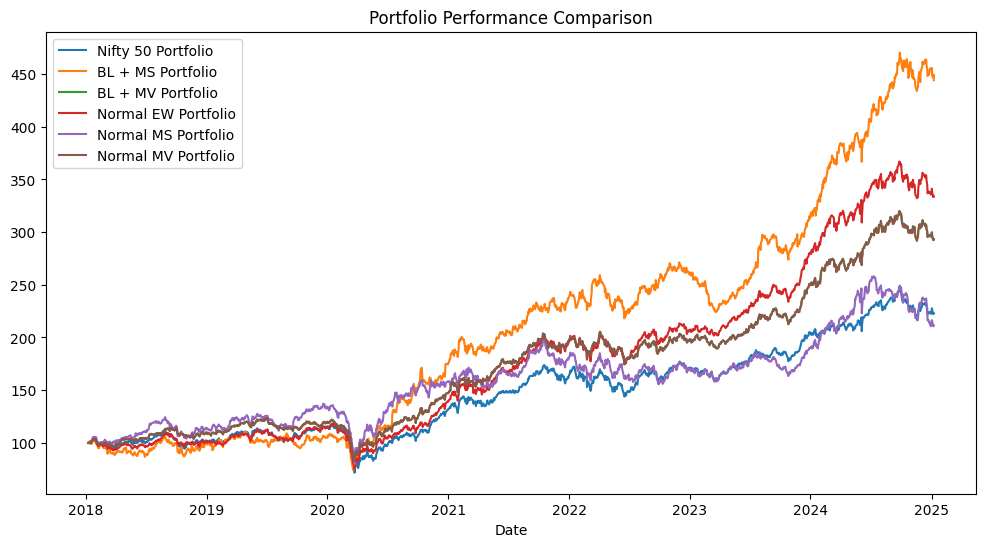

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(nifty50_dates, nifty50_portfolio, label='Nifty 50 Portfolio')
plt.plot(dates_BL_MS, portfolio_value_BL_MS, label='BL + MS Portfolio')
plt.plot(dates_BL_MV, portfolio_value_BL_MV, label='BL + MV Portfolio')
plt.plot(dates_normal_ew, portfolio_value_normal_ew, label='Normal EW Portfolio')
plt.plot(dates_normal_ms, portfolio_value_normal_ms, label='Normal MS Portfolio')
plt.plot(dates_normal_mv, portfolio_value_normal_mv, label='Normal MV Portfolio')
plt.xlabel('Date')
plt.title('Portfolio Performance Comparison')
plt.legend()

In [102]:
# make a dataframe for metrics
metrics = pd.DataFrame(columns=["Sharpe Ratio", "Sortino Ratio", "Volatility"])

for i, portfolio in enumerate([nifty50_portfolio ,portfolio_value_BL_MS, portfolio_value_BL_MV, portfolio_value_normal_ew, portfolio_value_normal_ms, portfolio_value_normal_mv]):
    portfolio_name = ["Nifty 50","BL + MS Portfolio", "BL + MV Portfolio", "Normal EW Portfolio", "Normal MS Portfolio", "Normal MV Portfolio"][i]
    metrics.loc[portfolio_name, "Sharpe Ratio"] = get_sharpe_ratio(pd.Series(portfolio))
    metrics.loc[portfolio_name, "Sortino Ratio"] = get_sortino_ratio(pd.Series(portfolio))
    metrics.loc[portfolio_name, "Volatility"] = get_volatility(pd.Series(portfolio))
    metrics.loc[portfolio_name, "Annualized Returns"] = get_annualized_returns(portfolio)
    metrics.loc[portfolio_name, "Max Drawdown"] = min(get_max_drawdown(pd.Series(portfolio)))

# include nifty 50 portfolio in the metrics dataframe


metrics

,Sharpe Ratio,Sortino Ratio,Volatility,Annualized Returns,Max Drawdown
Nifty 50,0.363193,0.430397,0.177013,0.124290,-0.384399
BL + MS Portfolio,0.887378,1.29192,0.205461,0.242321,-0.330021
BL + MV Portfolio,0.706372,0.900272,0.155038,0.169515,-0.333013
Normal EW Portfolio,0.776371,0.946834,0.169599,0.191672,-0.364420
Normal MS Portfolio,0.258562,0.333581,0.213124,0.115106,-0.417798
Normal MV Portfolio,0.705383,0.899676,0.155071,0.169384,-0.333054


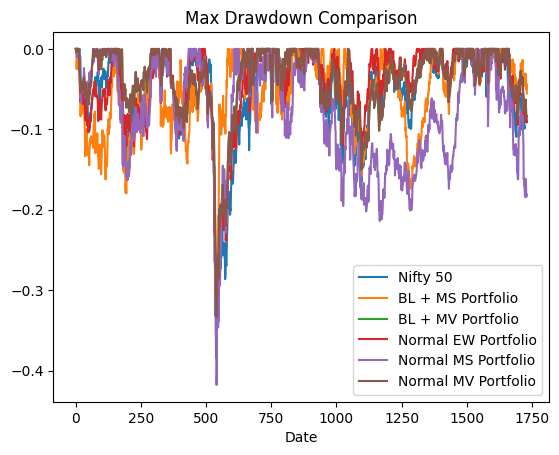

In [103]:
plt.plot(get_max_drawdown(nifty50_portfolio), label="Nifty 50")
plt.plot(get_max_drawdown(portfolio_value_BL_MS), label="BL + MS Portfolio")
plt.plot(get_max_drawdown(portfolio_value_BL_MV), label="BL + MV Portfolio")
plt.plot(get_max_drawdown(portfolio_value_normal_ew), label="Normal EW Portfolio")
plt.plot(get_max_drawdown(portfolio_value_normal_ms), label="Normal MS Portfolio")
plt.plot(get_max_drawdown(portfolio_value_normal_mv), label="Normal MV Portfolio")

plt.title("Max Drawdown Comparison")
plt.xlabel("Date")
plt.legend()

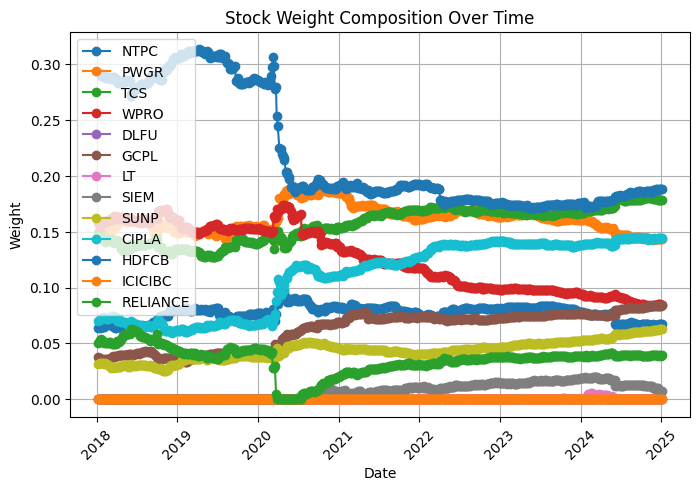

In [110]:
df = pd.DataFrame(W_BL_MV, index=dates_BL_MV[::3][:-1])


plt.figure(figsize=(8, 5))
for column in df.columns:
    plt.plot(df.index, df[column], marker="o", linestyle="-", label=column)

# Formatting
plt.xlabel("Date")
plt.ylabel("Weight")
plt.title("Stock Weight Composition Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [106]:
calculate_yearly_metrics(portfolio_value_BL_MS, dates_BL_MS)

,Annual Return (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Volatility (%)
Year,,,,,
2018,-0.313340,-0.282411,-0.417132,-17.982055,22.355144
2019,4.593998,-0.071600,-0.106422,-14.256191,19.636909
2020,65.746190,1.809926,2.635651,-31.860507,33.010290
2021,36.063131,1.833035,3.076246,-8.782934,16.400740
2022,8.311196,0.137794,0.238175,-15.865071,16.772799
2023,20.958790,1.093459,1.507505,-14.354867,13.680243
2024,45.435143,2.509458,3.665949,-7.747262,15.714608
2025,-66.110188,-4.873479,-5.858353,-2.543419,14.796451


In [107]:
calculate_yearly_metrics(portfolio_value_normal_ew, dates_normal_ew)

,Annual Return (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Volatility (%)
Year,,,,,
2018,1.536626,-0.330486,-0.570383,-12.120525,13.505491
2019,12.437662,0.478713,0.795955,-10.669919,13.447851
2020,21.121405,0.539462,0.574870,-36.441963,28.030518
2021,40.813732,2.202244,3.076691,-7.873741,15.808301
2022,4.363943,-0.099365,-0.138888,-13.323652,16.465060
2023,36.142149,3.126088,5.064495,-6.478939,9.642129
2024,20.257037,0.907330,1.091237,-9.475506,15.713169
2025,-39.257505,-2.961811,-5.285909,-2.289886,15.280349


In [111]:
calculate_yearly_metrics(portfolio_value_BL_MV, dates_BL_MV)

,Annual Return (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Volatility (%)
Year,,,,,
2018,10.134482,0.370888,0.561045,-9.088255,11.147530
2019,8.200818,0.196573,0.326297,-9.814098,11.195954
2020,22.707147,0.641544,0.713447,-32.500659,26.042089
2021,34.270727,1.919434,2.966222,-7.563677,14.728680
2022,-1.062923,-0.461127,-0.678978,-14.998743,15.316642
2023,27.576843,2.189766,3.750229,-6.611188,9.853490
2024,18.175852,0.859382,1.170484,-8.778509,14.168151
2025,-39.137999,-2.953271,-4.255071,-2.421011,15.284071


In [112]:
calculate_yearly_metrics(portfolio_value_normal_ms, dates_normal_ms)

,Annual Return (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Volatility (%)
Year,,,,,
2018,14.604100,0.566435,0.784960,-16.317325,15.189915
2019,16.442984,0.666700,1.307705,-12.674680,15.663696
2020,18.806691,0.346552,0.430587,-41.234310,36.954585
2021,14.486340,0.468507,0.740322,-13.259984,18.113596
2022,-7.400461,-0.684122,-0.993818,-16.227426,19.587836
2023,11.524978,0.439351,0.677409,-11.991786,12.575305
2024,11.550269,0.258805,0.299917,-18.394205,21.445764
2025,-35.449391,-2.003632,-2.343484,-2.682765,20.687131


In [113]:
calculate_yearly_metrics(portfolio_value_normal_mv, dates_normal_mv)

,Annual Return (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Volatility (%)
Year,,,,,
2018,10.178120,0.374810,0.567621,-9.056410,11.147310
2019,8.207683,0.197073,0.327213,-9.823354,11.202365
2020,22.714772,0.641640,0.713770,-32.490375,26.050063
2021,34.238097,1.916269,2.962529,-7.545375,14.735975
2022,-1.121005,-0.464764,-0.684782,-15.026283,15.321752
2023,27.524535,2.182339,3.739136,-6.597144,9.863060
2024,18.167167,0.859647,1.173625,-8.778021,14.153673
2025,-39.074902,-2.948863,-4.269339,-2.423997,15.285520


In [101]:
print('done')

done


In [114]:
# save the lists in a folder called weights
import os
import pickle
if not os.path.exists("weights"):
    os.makedirs("weights")

# portfolio_value_BL_MS, dates_BL_MS, W_BL_MS = backtest(max_sharpe_ratio)
# portfolio_value_BL_MV, dates_BL_MV, W_BL_MV = backtest(min_volatility_weights)

with open("weights/portfolio_value_BL_MS.pkl", "wb") as f:
    pickle.dump(portfolio_value_BL_MS, f)
with open("weights/dates_BL_MS.pkl", "wb") as f:
    pickle.dump(dates_BL_MS, f)
with open("weights/W_BL_MS.pkl", "wb") as f:
    pickle.dump(W_BL_MS, f)
with open("weights/portfolio_value_BL_MV.pkl", "wb") as f:
    pickle.dump(portfolio_value_BL_MV, f)
with open("weights/dates_BL_MV.pkl", "wb") as f:
    pickle.dump(dates_BL_MV, f)
with open("weights/W_BL_MV.pkl", "wb") as f:
    pickle.dump(W_BL_MV, f)

